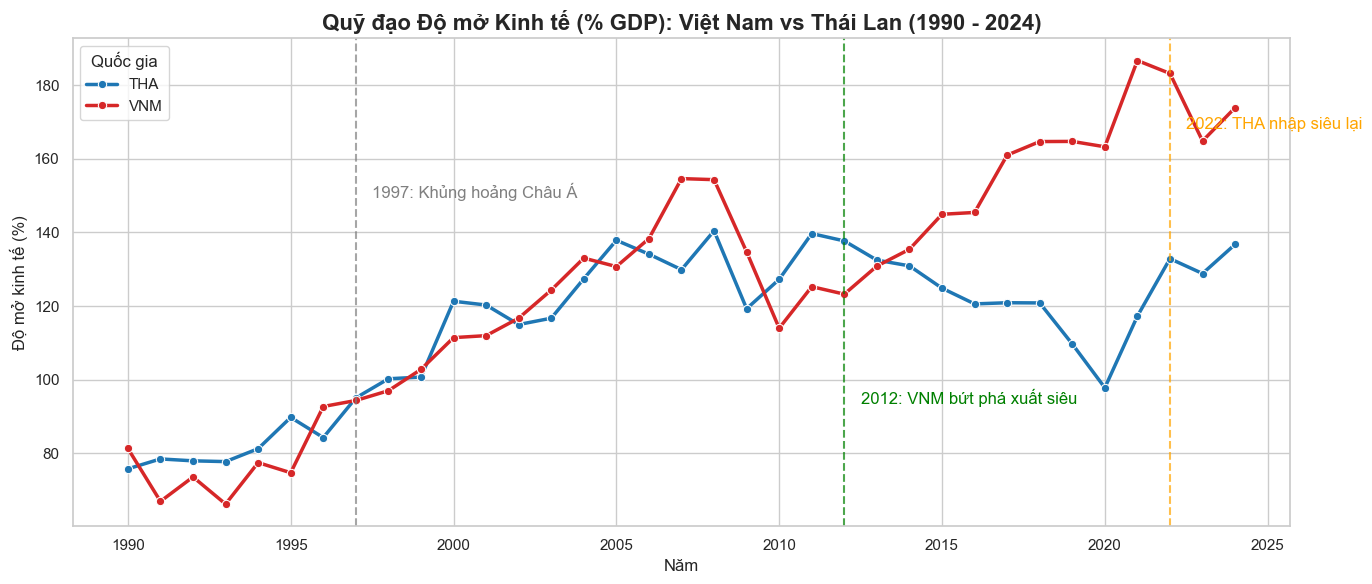

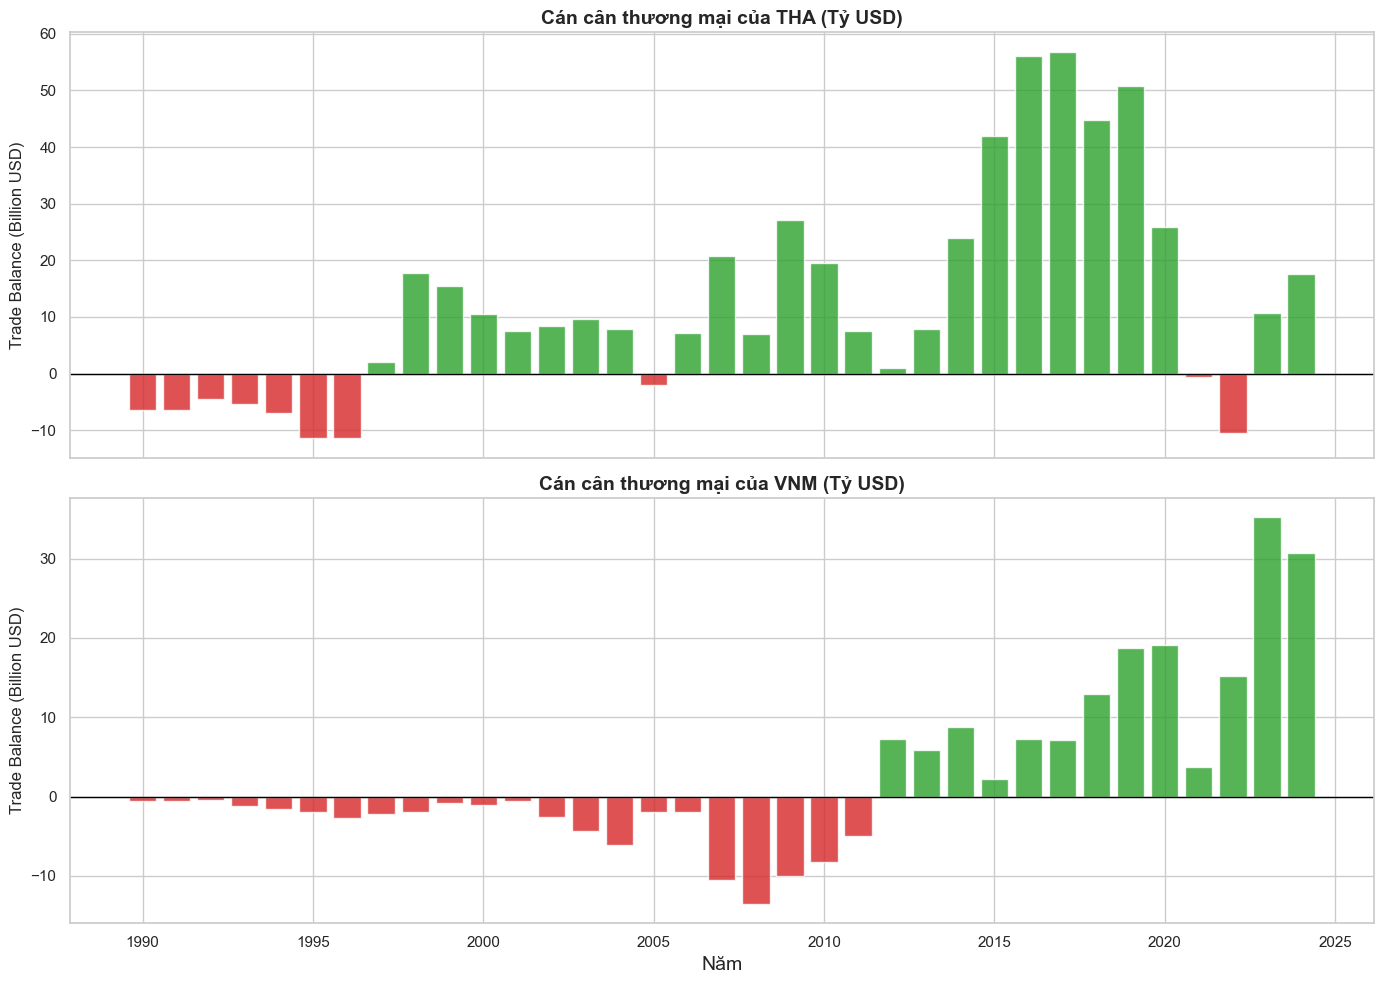

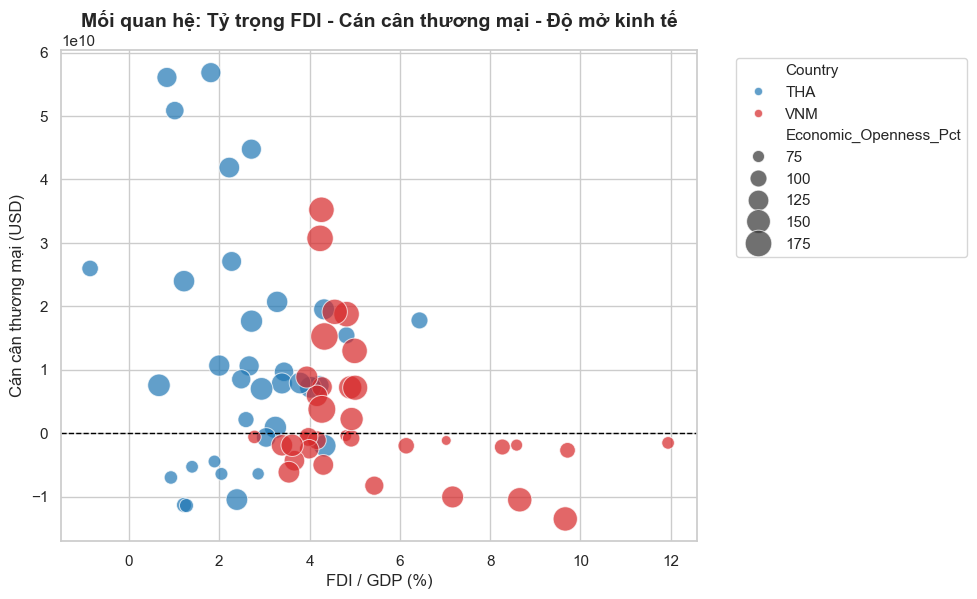

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cài đặt style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# 1. TẢI VÀ LỌC DỮ LIỆU
# Thay đổi đường dẫn nếu cần thiết
file_path = 'cleaned_data/information/panel_macro_cleaned.csv'
df = pd.read_csv(file_path)

# Lọc dữ liệu riêng cho Việt Nam và Thái Lan
df_compare = df[df['Country'].isin(['VNM', 'THA'])].copy()

# 2. VẼ BIỂU ĐỒ 1: ĐỘ MỞ KINH TẾ (ECONOMIC OPENNESS)
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare, x='Year', y='Economic_Openness_Pct', hue='Country', 
             linewidth=2.5, marker='o', palette={'VNM': '#d62728', 'THA': '#1f77b4'})

# Thêm các mốc sự kiện (Structural Breaks)
plt.axvline(x=1997, color='gray', linestyle='--', alpha=0.7)
plt.text(1997.5, df_compare['Economic_Openness_Pct'].max()*0.8, '1997: Khủng hoảng Châu Á', color='gray')

plt.axvline(x=2012, color='green', linestyle='--', alpha=0.7)
plt.text(2012.5, df_compare['Economic_Openness_Pct'].max()*0.5, '2012: VNM bứt phá xuất siêu', color='green')

plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.7)
plt.text(2022.5, df_compare['Economic_Openness_Pct'].max()*0.9, '2022: THA nhập siêu lại', color='orange')

plt.title('Quỹ đạo Độ mở Kinh tế (% GDP): Việt Nam vs Thái Lan (1990 - 2024)', fontsize=16, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Độ mở kinh tế (%)', fontsize=12)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

# 3. VẼ BIỂU ĐỒ 2: CÁN CÂN THƯƠNG MẠI & SỰ CHUYỂN ĐỔI
# Tạo 2 subplots trên dưới cho dễ so sánh
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for i, country in enumerate(['THA', 'VNM']):
    country_data = df_compare[df_compare['Country'] == country]
    
    # Chia màu: Xanh cho Xuất siêu (>0), Đỏ cho Nhập siêu (<0)
    colors = ['#2ca02c' if val >= 0 else '#d62728' for val in country_data['Trade_Balance_USD']]
    
    axes[i].bar(country_data['Year'], country_data['Trade_Balance_USD'] / 1e9, color=colors, alpha=0.8) # Chia 1e9 để hiển thị Tỷ USD
    axes[i].set_title(f'Cán cân thương mại của {country} (Tỷ USD)', fontsize=14, fontweight='bold')
    axes[i].axhline(0, color='black', linewidth=1)
    axes[i].set_ylabel('Trade Balance (Billion USD)')

plt.xlabel('Năm', fontsize=14)
plt.tight_layout()
plt.show()

# 4. VẼ BIỂU ĐỒ 3: KIỂM CHỨNG CHẤT LƯỢNG TĂNG TRƯỞNG (FDI & GNI GAP)
# Biểu đồ phân tán (Scatter) xem mối quan hệ giữa FDI và Xuất siêu
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_compare, x='FDI_to_GDP_Pct', y='Trade_Balance_USD', hue='Country', 
                size='Economic_Openness_Pct', sizes=(50, 400), alpha=0.7, palette={'VNM': '#d62728', 'THA': '#1f77b4'})

plt.title('Mối quan hệ: Tỷ trọng FDI - Cán cân thương mại - Độ mở kinh tế', fontsize=14, fontweight='bold')
plt.xlabel('FDI / GDP (%)', fontsize=12)
plt.ylabel('Cán cân thương mại (USD)', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

--- KẾT QUẢ TƯƠNG QUAN: FDI & CÁN CÂN THƯƠNG MẠI (THÁI LAN) ---
Giai đoạn 1997 - 2011 (Hoàng kim): Hệ số tương quan r = 0.134
Giai đoạn 2012 - 2024 (Bão hòa): Hệ số tương quan r = -0.464



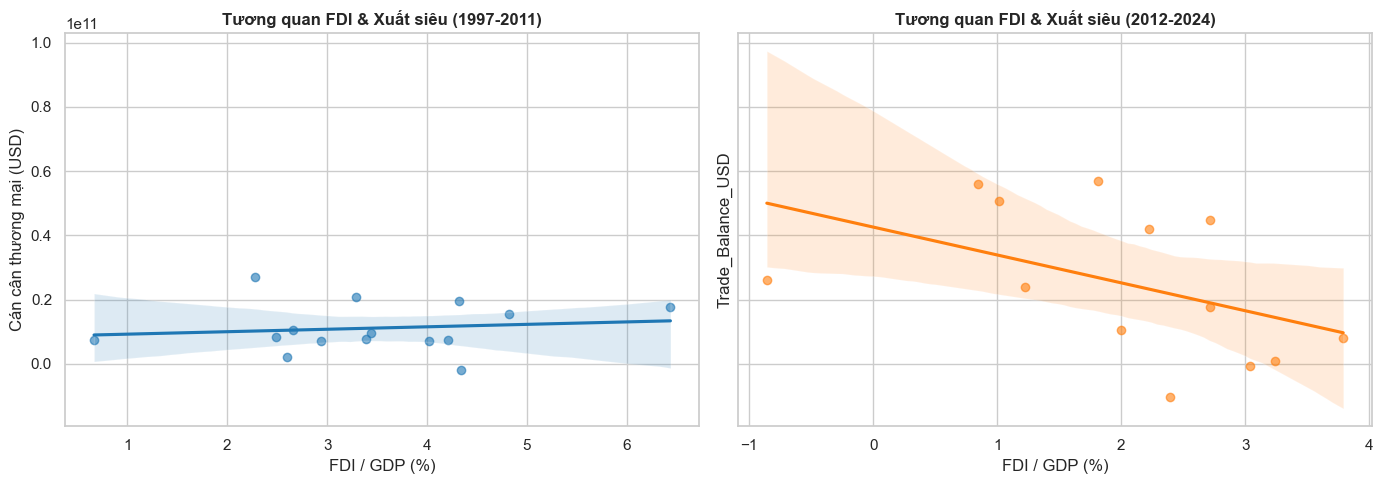

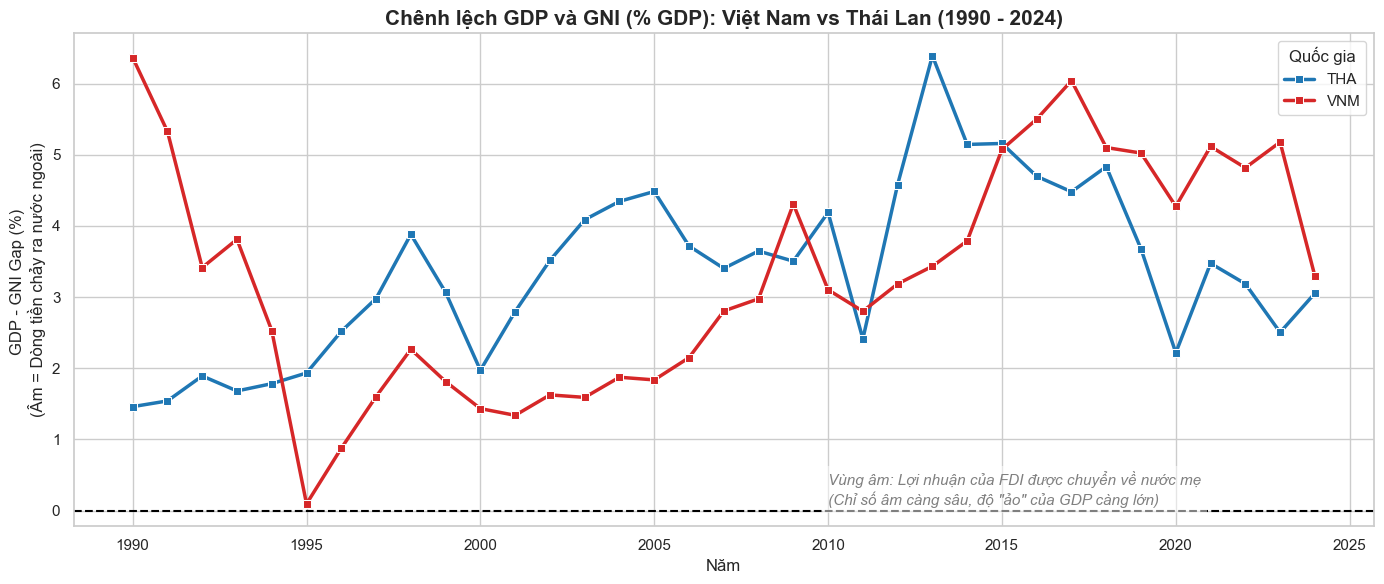

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Cài đặt style
sns.set_theme(style="whitegrid")

# Giả sử bạn đã load data từ trước, nếu chưa thì bỏ comment dòng dưới:
# df = pd.read_csv('cleaned_data/information/panel_macro_cleaned.csv')
df_compare = df[df['Country'].isin(['VNM', 'THA'])].copy()

# ==========================================
# BƯỚC 4: KIỂM ĐỊNH TƯƠNG QUAN FDI & CÁN CÂN THƯƠNG MẠI (THÁI LAN)
# ==========================================
print("--- KẾT QUẢ TƯƠNG QUAN: FDI & CÁN CÂN THƯƠNG MẠI (THÁI LAN) ---")
df_tha = df_compare[df_compare['Country'] == 'THA'].copy()

# Xử lý missing data để tính tương quan
df_tha_clean = df_tha.dropna(subset=['FDI_to_GDP_Pct', 'Trade_Balance_USD'])

# Chia 2 giai đoạn: Tăng trưởng vàng (1997-2011) và Giai đoạn sau (2012-2024)
tha_period_1 = df_tha_clean[(df_tha_clean['Year'] >= 1997) & (df_tha_clean['Year'] <= 2011)]
tha_period_2 = df_tha_clean[(df_tha_clean['Year'] >= 2012) & (df_tha_clean['Year'] <= 2024)]

if not tha_period_1.empty and not tha_period_2.empty:
    corr_1, _ = pearsonr(tha_period_1['FDI_to_GDP_Pct'], tha_period_1['Trade_Balance_USD'])
    corr_2, _ = pearsonr(tha_period_2['FDI_to_GDP_Pct'], tha_period_2['Trade_Balance_USD'])

    print(f"Giai đoạn 1997 - 2011 (Hoàng kim): Hệ số tương quan r = {corr_1:.3f}")
    print(f"Giai đoạn 2012 - 2024 (Bão hòa): Hệ số tương quan r = {corr_2:.3f}\n")

    # Trực quan hóa bằng Regression Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    sns.regplot(data=tha_period_1, x='FDI_to_GDP_Pct', y='Trade_Balance_USD', ax=axes[0], color='#1f77b4', scatter_kws={'alpha':0.6})
    axes[0].set_title('Tương quan FDI & Xuất siêu (1997-2011)', fontweight='bold')
    axes[0].set_xlabel('FDI / GDP (%)')
    axes[0].set_ylabel('Cán cân thương mại (USD)')
    
    sns.regplot(data=tha_period_2, x='FDI_to_GDP_Pct', y='Trade_Balance_USD', ax=axes[1], color='#ff7f0e', scatter_kws={'alpha':0.6})
    axes[1].set_title('Tương quan FDI & Xuất siêu (2012-2024)', fontweight='bold')
    axes[1].set_xlabel('FDI / GDP (%)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Không đủ dữ liệu để tính toán tương quan.")

# ==========================================
# BƯỚC 5: PHÂN TÍCH DÒNG TIỀN THỰC TẾ (GDP vs GNI GAP)
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare, x='Year', y='GDP_GNI_Gap_Pct', hue='Country', 
             linewidth=2.5, marker='s', palette={'VNM': '#d62728', 'THA': '#1f77b4'})

# Đường baseline 0 (Mức cân bằng)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

plt.title('Chênh lệch GDP và GNI (% GDP): Việt Nam vs Thái Lan (1990 - 2024)', fontsize=15, fontweight='bold')
plt.ylabel('GDP - GNI Gap (%) \n(Âm = Dòng tiền chảy ra nước ngoài)', fontsize=12)
plt.xlabel('Năm', fontsize=12)

# Chú thích thêm để dễ đọc biểu đồ
min_gap = df_compare['GDP_GNI_Gap_Pct'].min()
plt.text(2010, min_gap * 0.9, 'Vùng âm: Lợi nhuận của FDI được chuyển về nước mẹ\n(Chỉ số âm càng sâu, độ "ảo" của GDP càng lớn)', 
         color='gray', fontsize=11, style='italic', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

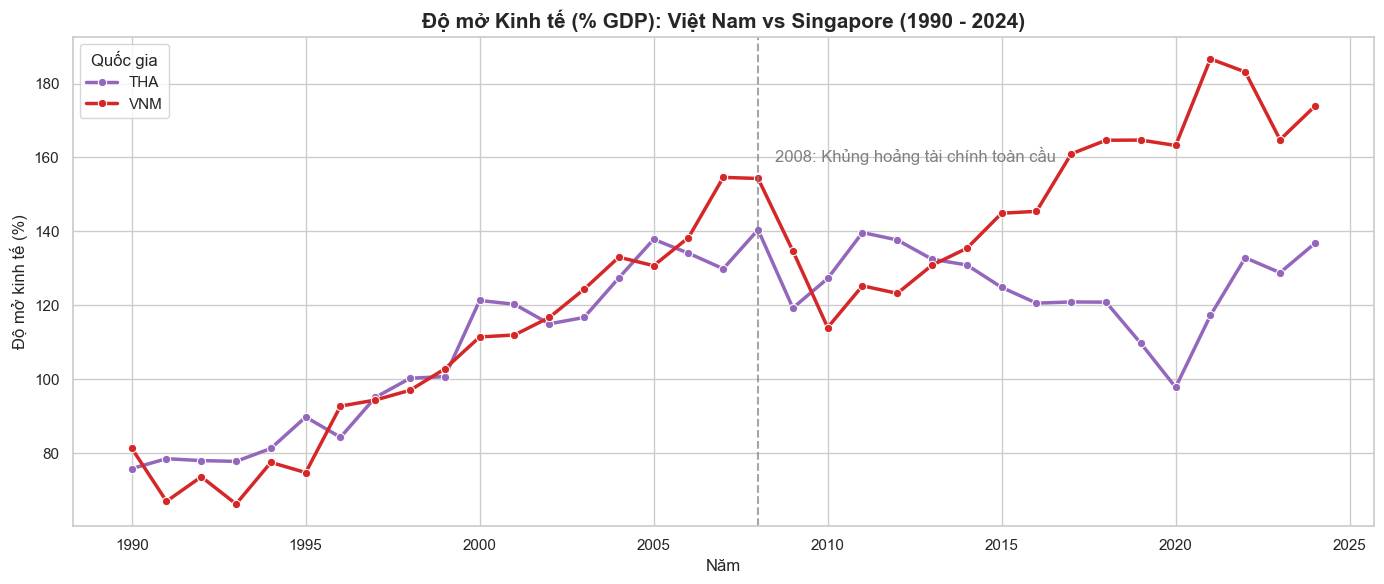

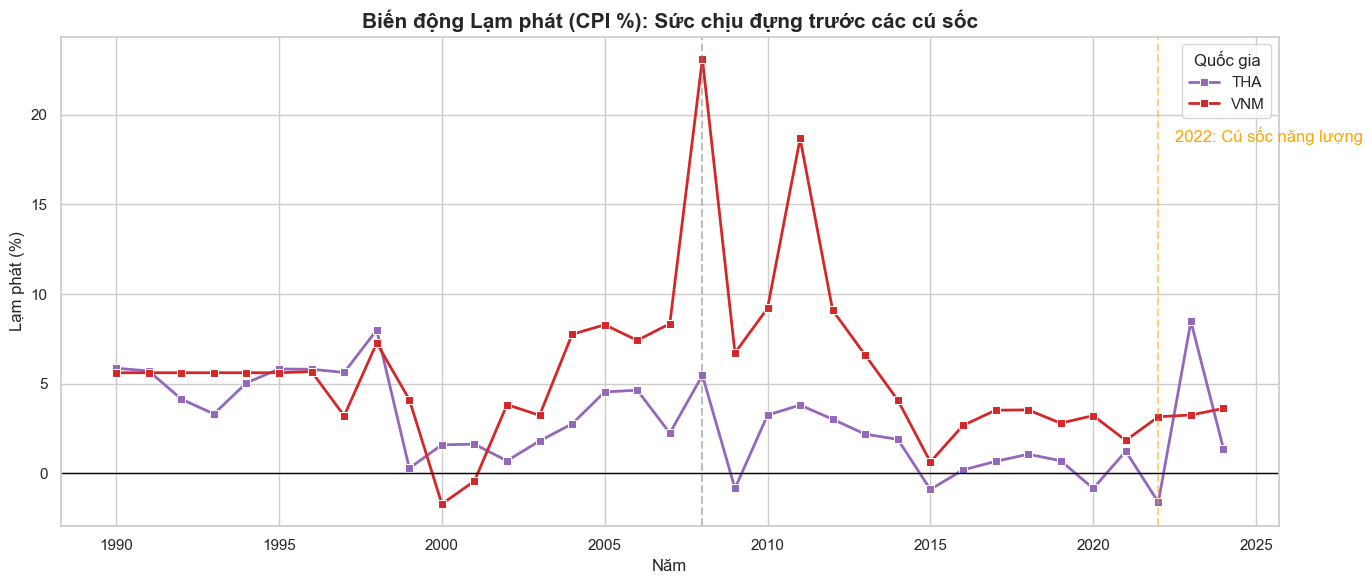

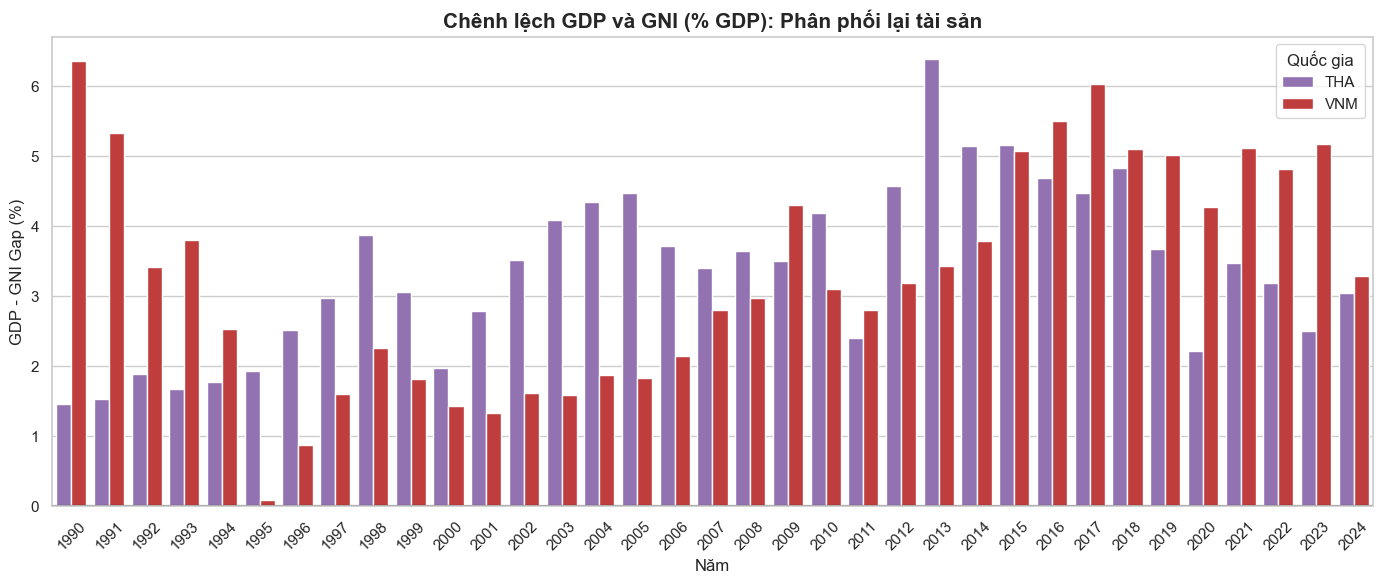

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style
sns.set_theme(style="whitegrid")

# Giả sử bạn đã load data từ trước:
df = pd.read_csv('cleaned_data/information/panel_macro_cleaned.csv')

# Lọc dữ liệu cho Việt Nam và Singapore
df_compare_THA = df[df['Country'].isin(['VNM', 'THA'])].copy()

# ==========================================
# BIỂU ĐỒ 1: QUỸ ĐẠO ĐỘ MỞ KINH TẾ (SỰ ĐIỀU CHỈNH CỦA THA)
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare_THA, x='Year', y='Economic_Openness_Pct', hue='Country', 
             linewidth=2.5, marker='o', palette={'VNM': '#d62728', 'THA': '#9467bd'})

# Thêm mốc khủng hoảng toàn cầu
plt.axvline(x=2008, color='gray', linestyle='--', alpha=0.7)
plt.text(2008.5, df_compare_THA['Economic_Openness_Pct'].max()*0.85, '2008: Khủng hoảng tài chính toàn cầu', color='gray')

plt.title('Độ mở Kinh tế (% GDP): Việt Nam vs Singapore (1990 - 2024)', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Độ mở kinh tế (%)', fontsize=12)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 2: BỘ ĐẶM VĨ MÔ & KHẢ NĂNG CHỐNG SỐC (LẠM PHÁT)
# ==========================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_compare_THA, x='Year', y='Inflation_CPI_Pct', hue='Country', 
             linewidth=2, marker='s', palette={'VNM': '#d62728', 'THA': '#9467bd'})

plt.axhline(0, color='black', linewidth=1)
plt.axvline(x=2008, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5)
plt.text(2022.5, df_compare_THA['Inflation_CPI_Pct'].max()*0.8, '2022: Cú sốc năng lượng', color='orange')

plt.title('Biến động Lạm phát (CPI %): Sức chịu đựng trước các cú sốc', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Lạm phát (%)', fontsize=12)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()

# ==========================================
# BIỂU ĐỒ 3: BẢN CHẤT CỦA SỰ SIÊU MỞ (GDP VS GNI GAP)
# ==========================================
plt.figure(figsize=(14, 6))
sns.barplot(data=df_compare_THA, x='Year', y='GDP_GNI_Gap_Pct', hue='Country', palette={'VNM': '#d62728', 'THA': '#9467bd'})

plt.axhline(0, color='black', linewidth=1.5)
plt.title('Chênh lệch GDP và GNI (% GDP): Phân phối lại tài sản', fontsize=15, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('GDP - GNI Gap (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Quốc gia')
plt.tight_layout()
plt.show()